In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Connect to the SQLite database
conn = sqlite3.connect("sales_data.db")


In [3]:
# Query 1: Product-wise quantity and revenue
query1 = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

df_summary = pd.read_sql_query(query1, conn)


In [4]:
print("----- Sales Summary by Product -----")
print(df_summary)


----- Sales Summary by Product -----
    product  total_qty  revenue
0    Eraser         12     36.0
1  Notebook          8    320.0
2       Pen         18    270.0
3    Pencil         20    100.0


In [5]:
query2 = """
SELECT 
    SUM(quantity) AS total_quantity_sold,
    SUM(quantity * price) AS total_revenue
FROM sales
"""

df_totals = pd.read_sql_query(query2, conn)
print("\n----- Overall Sales Totals -----")
print(df_totals)



----- Overall Sales Totals -----
   total_quantity_sold  total_revenue
0                   58          726.0


In [6]:
conn.close()


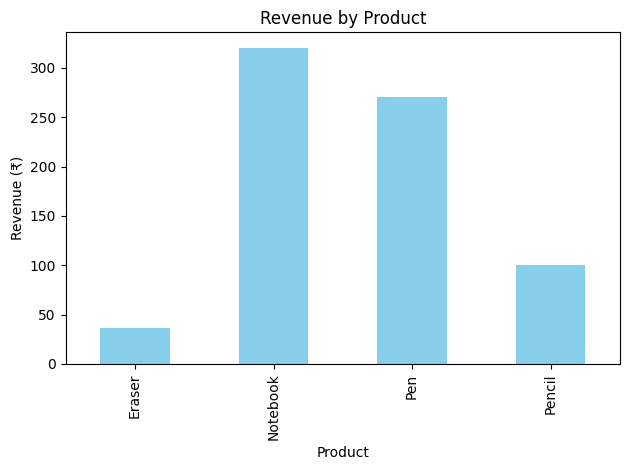

In [7]:
df_summary.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: Save the chart
plt.show()
